In [2]:
# pip install xarray netCDF4 pandas numpy scikit-learn xgboost joblib

import numpy as np
import pandas as pd
import xarray as xr
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import joblib


In [3]:
import glob
import xarray as xr
PATH = "/Users/lb962/Documents/GitHub/ESL_stats/data/ml4_removed/*"

# Get sorted list of files
files = sorted(glob.glob(PATH))

# Open each file into a list of datasets
datasets = [xr.open_dataset(f) for f in files]

# Example: inspect or process one
for i, ds in enumerate(datasets):
    print(f"File {i}: {files[i]}")
    print(ds)

# If you want them in memory:
datasets = [ds.load() for ds in datasets]


File 0: /Users/lb962/Documents/GitHub/ESL_stats/data/ml4_removed/station_1.nc
<xarray.Dataset> Size: 58MB
Dimensions:              (valid_time: 750192)
Coordinates:
    station              int64 8B ...
  * valid_time           (valid_time) datetime64[ns] 6MB 1940-01-01 ... 2025-...
    latitude             float64 8B ...
    longitude            float64 8B ...
    station_latitude     float64 8B ...
    station_longitude    float64 8B ...
    year                 (valid_time) int64 6MB ...
Data variables: (12/15)
    u10                  (valid_time) float32 3MB ...
    v10                  (valid_time) float32 3MB ...
    d2m                  (valid_time) float32 3MB ...
    t2m                  (valid_time) float32 3MB ...
    msl                  (valid_time) float32 3MB ...
    sst                  (valid_time) float32 3MB ...
    ...                   ...
    mwp                  (valid_time) float32 3MB ...
    swh                  (valid_time) float32 3MB ...
    sea_level     

In [4]:
ds = xr.concat(datasets, dim='station')

In [5]:
ds

<xarray.Dataset> Size: 14GB
Dimensions:              (station: 295, valid_time: 750192)
Coordinates:
  * station              (station) int64 2kB 1 10 102 103 104 ... 94 95 96 97 99
  * valid_time           (valid_time) datetime64[ns] 6MB 1940-01-01 ... 2025-...
    latitude             float64 8B 48.38
    longitude            float64 8B -4.495
    station_latitude     (station) float64 2kB 48.38 45.57 50.1 ... 49.18 49.48
    station_longitude    (station) float64 2kB -4.495 -1.062 ... -2.117 0.1146
    year                 (valid_time) int64 6MB 1940 1940 1940 ... 2025 2025
Data variables: (12/15)
    u10                  (station, valid_time) float32 885MB -4.661 ... 5.358
    v10                  (station, valid_time) float32 885MB 7.723 ... 1.459
    d2m                  (station, valid_time) float32 885MB 277.2 ... 289.0
    t2m                  (station, valid_time) float32 885MB 280.1 ... 290.9
    msl                  (station, valid_time) float32 885MB 1.014e+05 ... 1....
    sst                  (station, valid_time) float32 885MB 283.5 ... 292.2
    ...                   ...
    mwp                  (station, valid_time) float32 885MB nan nan ... 3.357
    swh                  (station, valid_time) float32 885MB nan nan ... 0.4357
    sea_level            (station, valid_time) float32 885MB nan nan ... nan nan
    tide                 (station, valid_time) float64 2GB -1.239 ... 0.7854
    residual             (station, valid_time) float32 885MB nan nan ... nan nan
    residual_is_deviant  (station, valid_time) int8 221MB 0 0 0 0 0 ... 0 0 0 0
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2024-09-02T04:48 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

# Select times and days where GEV is fitted

In [6]:
import warnings
warnings.filterwarnings("ignore")

In [7]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy import stats as st
import pandas as pd
from sklearn.cluster import KMeans  # (still unused)

# --- config ---
TARGET_VAR = "residual"
N_STATIONS = 295
CSV_OUT = "gev_fit_scoresEW.csv"
BIMONTHLY_OUT = "bimonthly_values_at_gev_timesEW.csv"
RESAMPLE_RULE = "2M"  # 2-month blocks (month-end anchored)

if TARGET_VAR not in ds.data_vars:
    # fall back to "first numeric data var" if residual isn't present
    for v in ds.data_vars:
        if np.issubdtype(ds[v].dtype, np.number):
            TARGET_VAR = v
            print(f"Using variable '{TARGET_VAR}' (first numeric data variable).")
            break
    else:
        raise ValueError("No numeric data variable found to fit.")

# Helper to safely get station coordinates for labeling
def _meta_for_station(i):
    lat = None
    lon = None
    try:
        lat = float(ds["station_latitude"].sel(station=i))
        lon = float(ds["station_longitude"].sel(station=i))
    except Exception:
        try:
            lat = float(ds["latitude"])
            lon = float(ds["longitude"])
        except Exception:
            pass
    return lat, lon

# Helper to get the time dimension for a single-station DataArray
def _time_dim(da):
    candidates = [d for d in da.dims if d not in ("station", "stations")]
    if not candidates:
        raise ValueError("Could not infer time dimension.")
    return candidates[0]

# Goodness-of-fit helpers
def kuiper_statistic(x, cdf_func):
    x = np.sort(np.asarray(x))
    n = x.size
    i = np.arange(1, n + 1)
    F_emp = i / n
    F_mod = cdf_func(x)
    D_plus = np.max(F_emp - F_mod)
    D_minus = np.max(F_mod - (i - 1) / n)
    return D_plus + D_minus

def r2_cdf_fit(x, cdf_func):
    x = np.sort(np.asarray(x))
    n = x.size
    i = np.arange(1, n + 1)
    F_emp = i / (n + 1.0)
    F_mod = cdf_func(x)
    ss_res = np.sum((F_emp - F_mod) ** 2)
    ss_tot = np.sum((F_emp - np.mean(F_emp)) ** 2)
    if ss_tot == 0:
        return np.nan
    return 1 - ss_res / ss_tot

stations = np.array(ds["station"].values)[:N_STATIONS]

fit_results = []
bimonthly_rows = []

# Eligible variables for extraction:
# keep only data_vars that are scalar per (station,time), i.e. dims subset of {station, tdim}
# (we will decide tdim per station from TARGET_VAR)
all_vars = list(ds.data_vars)

for s in stations:
    # DataArray for this station
    da = ds[TARGET_VAR].sel(station=s)

    # infer time dimension
    try:
        tdim = _time_dim(da)
    except Exception as e:
        print(f"Skipping station {s}: cannot infer time dim ({e}).")
        continue

    # drop NaNs/infs
    da = da.where(np.isfinite(da), drop=True)

    if da.size < 10:
        print(f"Skipping station {s}: not enough data after cleaning.")
        continue

    # 2-month block maxima and the time-of-maximum within each block
    try:
        r = da.resample({tdim: RESAMPLE_RULE})

        da_max = r.max()  # block maxima values (time coord is block label)
        # extraction time (timestamp at which the max occurred in the original series)
        da_tmax = r.map(lambda x: x.idxmax(dim=tdim))  # same block labels
    except Exception as e:
        print(f"Skipping station {s}: resample/idxmax failed ({e}).")
        continue

    # Flatten and clean maxima + extraction times consistently
    # (keep only blocks where both max and time-of-max are finite/non-null)
    valid = np.isfinite(da_max.values) & pd.notnull(da_tmax.values)
    if valid.sum() < 5:
        print(f"Skipping station {s}: not enough bimonthly maxima ({valid.sum()}).")
        continue

    x = da_max.values[valid].ravel()
    t_block = da_max[tdim].values[valid]      # block label timestamps (e.g., month-end)
    t_extract = da_tmax.values[valid].ravel() # actual timestamps of maxima

    # Fit GEV to block maxima
    gev_params = st.genextreme.fit(x)
    c, loc, scale = gev_params

    def gev_cdf(z):
        return st.genextreme.cdf(z, c, loc=loc, scale=scale)

    ks_stat, ks_p = st.kstest(x, "genextreme", args=gev_params)
    kuiper = kuiper_statistic(x, gev_cdf)
    r2 = r2_cdf_fit(x, gev_cdf)

    lat, lon = _meta_for_station(s)

    fit_results.append(
        {
            "station": int(s),
            "lat": lat,
            "lon": lon,
            "n_blocks": int(x.size),
            "gev_c": c,
            "gev_loc": loc,
            "gev_scale": scale,
            "ks_stat": ks_stat,
            "ks_pvalue": ks_p,
            "kuiper": kuiper,
            "r2_cdf": r2,
        }
    )

    # --- Subsample ds at extraction times to get bimonthly "event-aligned" values for every variable ---
    # Build an indexer with a NEW dimension "block" to avoid collisions with the original time dim name.
    extract_times = xr.DataArray(
        t_extract,
        dims=("block",),
        coords={"block": t_block},  # coordinate block labels for readability
        name="extract_time",
    )

    # Start each bimonthly row with station + block info + target max + extract_time
    base = pd.DataFrame(
        {
            "station": int(s),
            "block_time": pd.to_datetime(t_block),
            "extract_time": pd.to_datetime(t_extract),
            "target_block_max": x,
        }
    )

    # For each variable, extract values at the TARGET_VAR max-times (same station)
    # Only include variables that are scalar per (station,time): dims subset of {station, tdim}
    for v in all_vars:
        dv = ds[v]
        dims = set(dv.dims)

        if "station" not in dims or tdim not in dims:
            continue
        if not dims.issubset({"station", tdim}):
            # skip variables with extra dims (e.g., level, member, etc.)
            continue

        try:
            dv_s = dv.sel(station=s)
            # select at the extraction times; result will be indexed by "block"
            extracted = dv_s.sel({tdim: extract_times})
            # convert to 1D array aligned with base rows
            base[v] = np.asarray(extracted.values).ravel()
        except Exception:
            # if selection fails (e.g. non-unique times), skip safely
            continue

    bimonthly_rows.append(base)

# Save outputs
df_fit = pd.DataFrame(fit_results)
if df_fit.empty:
    raise RuntimeError("No stations were successfully fitted. Check your data and config.")
df_fit.to_csv(CSV_OUT, index=False)
print(f"Saved GEV fit parameters and scores to: {CSV_OUT}")

if bimonthly_rows:
    df_bi = pd.concat(bimonthly_rows, ignore_index=True)
    df_bi.to_csv(BIMONTHLY_OUT, index=False)
    print(f"Saved bimonthly values at GEV extraction times to: {BIMONTHLY_OUT}")
else:
    raise RuntimeError("No bimonthly extracted values were produced.")


Skipping station 110: not enough data after cleaning.
Skipping station 112: not enough data after cleaning.
Skipping station 113: not enough data after cleaning.
Skipping station 143: not enough data after cleaning.
Skipping station 145: not enough data after cleaning.
Skipping station 159: not enough data after cleaning.
Skipping station 276: not enough data after cleaning.
Skipping station 466: not enough data after cleaning.
Skipping station 472: not enough data after cleaning.
Skipping station 480: not enough data after cleaning.
Skipping station 518: not enough data after cleaning.
Skipping station 525: not enough data after cleaning.
Skipping station 557: not enough data after cleaning.
Skipping station 558: not enough data after cleaning.
Skipping station 564: not enough data after cleaning.
Skipping station 96: not enough data after cleaning.
Saved GEV fit parameters and scores to: gev_fit_scoresEW.csv
Saved bimonthly values at GEV extraction times to: bimonthly_values_at_gev_t

# Feature engineering

In [8]:
df_bi["wind_magnitude"] = np.sqrt((df_bi["u10"]**2 )* (df_bi["v10"]**2))
df_bi["wind_dir"] = np.degrees(np.arctan2(df_bi["u10"], df_bi["v10"])) % 360
df_bi["u10_abs"] = df_bi["u10"].abs()
df_bi["v10_abs"] = df_bi["v10"].abs()
df_bi["wind_wave_diff"] =  df_bi["mwd"] - df_bi["wind_dir"]
df_bi["wind_wave_alignment"] =  np.cos(df_bi["wind_dir"] - df_bi["mwd"])
rho_air = 1.225      # kg m-3
Cd = 1.3e-3          # neutral drag coefficient
df_bi["tau_u"] = rho_air * Cd * df_bi["wind_magnitude"] * df_bi["u10"]
df_bi["tau_u_abs"] = df_bi["tau_u"].abs()
df_bi["tau_v"] = rho_air * Cd * df_bi["wind_magnitude"]  * df_bi["v10"]
df_bi["tau_v_abs"] = df_bi["tau_v"].abs()
df_bi["tau_mag"] = rho_air * Cd * df_bi["wind_magnitude"] **2

In [9]:
del df_bi['target_block_max']
del df_bi['sea_level']

In [10]:
merge_columns = df_fit[['station', 'lat', 'lon']]
df_bi = df_bi.merge(merge_columns, on = 'station')

# coastal alignment

In [30]:
import numpy as np
import pandas as pd
import cartopy.io.shapereader as shpreader
from shapely.geometry import Point, LineString, MultiLineString
from shapely.ops import unary_union, nearest_points

# --------------------------
# helpers
# --------------------------
def bearing_deg(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.deg2rad, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    x = np.sin(dlon) * np.cos(lat2)
    y = np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(dlon)
    return (np.rad2deg(np.arctan2(x, y)) + 360) % 360

def ang_diff_deg(a, b):
    return (a - b + 180) % 360 - 180

def local_tangent_bearing(line, p_near):
    if not isinstance(line, LineString) or line.length == 0:
        return np.nan
    d0 = line.project(p_near)
    step = max(line.length * 0.02, 0.0005)
    d1 = np.clip(d0 - step, 0, line.length)
    d2 = np.clip(d0 + step, 0, line.length)
    p1 = line.interpolate(d1)
    p2 = line.interpolate(d2)
    return bearing_deg(p1.x, p1.y, p2.x, p2.y)

def tangent_bearing_near(coast_geom, lon, lat, radius_deg):
    p = Point(lon, lat)
    local = coast_geom.intersection(p.buffer(radius_deg))
    if local.is_empty:
        return np.nan, False

    if isinstance(local, MultiLineString):
        parts = list(local.geoms)
        line = parts[np.argmin([p.distance(g) for g in parts])]
    else:
        local_u = unary_union(local)
        if isinstance(local_u, MultiLineString):
            parts = list(local_u.geoms)
            line = parts[np.argmin([p.distance(g) for g in parts])]
        else:
            line = local_u

    if not isinstance(line, LineString) or line.length == 0:
        return np.nan, False

    try:
        p_near = nearest_points(p, line)[1]
    except Exception:
        return np.nan, False

    return local_tangent_bearing(line, p_near), True

def tangent_bearing_adaptive(coast_geom, lon, lat, radii):
    for r in radii:
        b, ok = tangent_bearing_near(coast_geom, lon, lat, r)
        if ok and np.isfinite(b):
            return b, r
    return np.nan, np.nan

def add_orientation_block(df, prefix, bearing_col):
    df[f"{prefix}_normal1_deg"] = (df[bearing_col] + 90) % 360
    df[f"{prefix}_normal2_deg"] = (df[bearing_col] - 90) % 360

    w = df["wind_to_mean_deg"]
    d1 = ang_diff_deg(w, df[f"{prefix}_normal1_deg"])
    d2 = ang_diff_deg(w, df[f"{prefix}_normal2_deg"])

    df[f"wind_vs_{prefix}_normal_diff_deg"] = np.where(np.abs(d1) < np.abs(d2), d1, d2)
    df[f"wind_more_{prefix}shore_deg"] = ang_diff_deg(w, df[bearing_col])
    return df

# --------------------------
# coastline geometry
# --------------------------
coast_shp = shpreader.natural_earth(resolution="10m", category="physical", name="coastline")
coast_geom = unary_union(list(shpreader.Reader(coast_shp).geometries()))

# --------------------------
# parameters
# --------------------------
#radii_narrow  = [0.01, 0.02]
radii_coastal = [0.1, 0.15, 0.2]
radii_bay     = [0.3, 0.4, 0.5]

df_bi["wind_to_mean_deg"] = (df_bi["wind_dir"] + 180) % 360

# --------------------------
# compute orientations
# --------------------------
rows = []
for _, r in df_bi[["station", "lon", "lat"]].dropna().iterrows():
    lon, lat = float(r.lon), float(r.lat)

    #nb, nr = tangent_bearing_adaptive(coast_geom, lon, lat, radii_narrow)
    cb, cr = tangent_bearing_adaptive(coast_geom, lon, lat, radii_coastal)
    bb, br = tangent_bearing_adaptive(coast_geom, lon, lat, radii_bay)

   # rows.append((r.station, nb, nr, cb, cr, bb, br))
    rows.append((r.station, cb, cr, bb, br))

orient_df = pd.DataFrame(
    rows,
    columns=[
        "station",
       # "narrow_bearing_deg",  "narrow_radius_used_deg",
        "coastal_bearing_deg", "coastal_radius_used_deg",
        "bay_bearing_deg",     "bay_radius_used_deg",
    ],
)
orient_df = orient_df.drop_duplicates()
stats_df = df_bi.merge(orient_df, on="station", how="left")
# optional complexity indicators

stats_df["coastal_vs_bay_diff_deg"] = np.abs(
   ang_diff_deg(stats_df["coastal_bearing_deg"], stats_df["bay_bearing_deg"])
)
stats_df = add_orientation_block(stats_df, "coastal", "coastal_bearing_deg")
stats_df = add_orientation_block(stats_df, "bay","bay_bearing_deg")

$$
\begin{array}{l l}
\hline
\textbf{Variable} & \textbf{Description} \\
\hline
\texttt{station} & \text{Unique station identifier.} \\
\texttt{lon} & \text{Station longitude (deg E).} \\
\texttt{lat} & \text{Station latitude (deg N).} \\
\texttt{wind\_dir\_mean} & \text{Mean wind direction (from), deg.} \\
\texttt{wind\_to\_mean\_deg} & \text{(wind\_dir\_mean + 180) mod 360.} \\
\texttt{coastal\_bearing\_deg} & \text{Coastal-scale shoreline tangent bearing.} \\
\texttt{coastal\_radius\_used\_deg} & \text{Radius used (deg) for coastal bearing.} \\
\texttt{coastal\_normal1\_deg} & \text{coastal\_bearing + 90.} \\
\texttt{coastal\_normal2\_deg} & \text{coastal\_bearing - 90.} \\
\texttt{wind\_vs\_coastal\_normal\_diff\_deg} & \text{Wind-to minus nearest coastal normal.} \\
\texttt{wind\_more\_coastalshore\_deg} & \text{Wind-to minus coastal tangent.} \\
\texttt{bay\_bearing\_deg} & \text{Bay-scale shoreline tangent bearing.} \\
\texttt{bay\_radius\_used\_deg} & \text{Radius used (deg) for bay bearing.} \\
\texttt{bay\_normal1\_deg} & \text{bay\_bearing + 90.} \\
\texttt{bay\_normal2\_deg} & \text{bay\_bearing - 90.} \\
\texttt{wind\_vs\_bay\_normal\_diff\_deg} & \text{Wind-to minus nearest bay normal.} \\
\texttt{wind\_more\_bayshore\_deg} & \text{Wind-to minus bay tangent.} \\
\texttt{coastal\_vs\_bay\_diff\_deg} & \text{Abs angular difference coastal vs bay bearing.} \\
\hline
\end{array}
$$


In [ ]:
stats_df.to_csv("intermittedly.csv")

In [1]:
import pandas as pd
stats_df = pd.read_csv("intermittedly.csv")

# add bathymetry stats

In [2]:
import os
import xarray as xr
import pandas as pd

import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Open the GEBCO NetCDF file
file_path = "/Users/lb962/Documents/Phd/AExtremesEOF/data/GEBCO/gebco_2024_n70.0_s47.0_w-20.0_e15.0.nc"
GEBCO_ds = xr.open_dataset(file_path)

latlon = stats_df[["lat", "lon"]]
# if you want unique lat/lon pairs:
unique_latlon = latlon.drop_duplicates().to_numpy()

In [3]:
import numpy as np
import xarray as xr

def compute_slope_aspect(ds, var="elevation"):
    
    z = ds[var]

    # grid spacing in degrees
    dlat = float(abs(ds.lat.diff("lat").mean()))
    dlon = float(abs(ds.lon.diff("lon").mean()))

    # convert degrees → meters
    R = 6371000  # Earth radius
    lat_rad = np.deg2rad(ds.lat)

    dy = dlat * np.pi/180 * R
    dx = dlon * np.pi/180 * R * np.cos(lat_rad)

    # compute gradients
    dz_dlat = z.differentiate("lat") / dy
    dz_dlon = z.differentiate("lon") / dx

    # slope (radians → degrees)
    slope = np.arctan(np.sqrt(dz_dlat**2 + dz_dlon**2))
    slope_deg = np.rad2deg(slope)

    # aspect
    aspect = np.arctan2(-dz_dlon, dz_dlat)
    aspect_deg = (np.rad2deg(aspect) + 360) % 360

    return xr.Dataset({
        "slope_deg": slope_deg,
        "aspect_deg": aspect_deg
    })

terrain = compute_slope_aspect(GEBCO_ds)
GEBCO_ds = xr.merge([GEBCO_ds, terrain])

In [4]:
roughness = GEBCO_ds.elevation.rolling(lat=5, lon=5, center=True).std()
GEBCO_ds["roughness"] = roughness

In [ ]:
# curvature and curvature in slope direction. pos: convex (ridge), neg: channel
d2z_dx2 = GEBCO_ds.elevation.differentiate("lon").differentiate("lon")
d2z_dy2 = GEBCO_ds.elevation.differentiate("lat").differentiate("lat")

GEBCO_ds["curvature"] = d2z_dx2 + d2z_dy2
GEBCO_ds["profile_curvature"] = d2z_dx2
# BPI value	terrain
#positive	ridge
#negative	valley
#~0	flat
def compute_bpi(ds, window=21):
    mean_z = ds.elevation.rolling(
        lat=window,
        lon=window,
        center=True
    ).mean()

    bpi = ds.elevation - mean_z
    return bpi
GEBCO_ds["bpi"] = compute_bpi(GEBCO_ds, window=21)

/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/core/duck_array_ops.py:228: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


: 

In [ ]:
window = 21

mean = GEBCO_ds.bpi.rolling(lat=window, lon=window, center=True).mean()
std = GEBCO_ds.bpi.rolling(lat=window, lon=window, center=True).std()

GEBCO_ds["bpi_norm"] = (GEBCO_ds.bpi - mean) / std

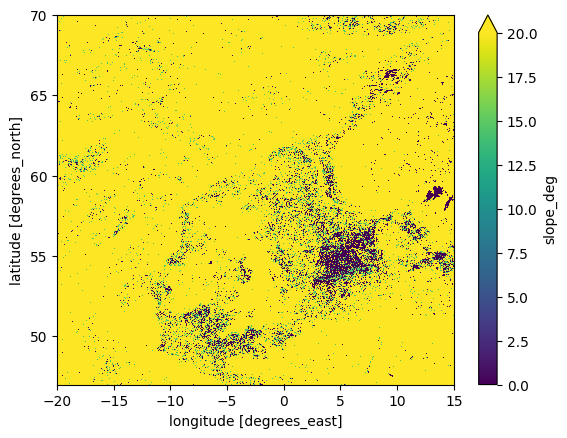

In [92]:
GEBCO_ds.slope_deg.plot(vmin=0, vmax=20)

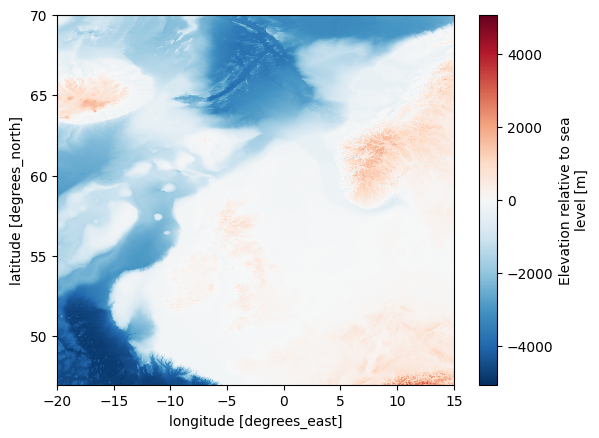

In [66]:
GEBCO_ds.elevation.plot()

In [87]:

results = {
    "0.1x0.1": [],
    "0.25x0.25": [],
    "1x1": [],
    "3x3": [],
    "10x10":[]
}

def mask_land_gt1m(ds_tile):
    """Mask elevations shallower than -0.5 m (land/coast) as NaN."""
    ds_masked = ds_tile.copy()
    ds_masked["elevation"] = ds_tile["elevation"].where(ds_tile["elevation"] <= -0.5)
    return ds_masked

def plot_tile(ds_tile, title="GEBCO bathymetry (masked, with station)"):
    """Plot a masked GEBCO tile with Cartopy and a red station dot at the center."""
    masked = mask_land_gt1m(ds_tile)

    # Compute the center coordinate (station location)
    center_lat = float(masked.lat.mean())
    center_lon = float(masked.lon.mean())
    
    fig = plt.figure(figsize=(6, 4))
    ax = plt.axes(projection=ccrs.PlateCarree())

    # Bathymetry raster
    pcm = ax.pcolormesh(
        masked["lon"], masked["lat"], masked["elevation"],
        transform=ccrs.PlateCarree()
    )

    # Coastlines and extent
    ax.coastlines(resolution="10m")
    ax.set_title(title)
    ax.set_extent([
        float(masked.lon.min()), float(masked.lon.max()),
        float(masked.lat.min()), float(masked.lat.max())
    ], crs=ccrs.PlateCarree())

    # Station red dot
    ax.plot(center_lon, center_lat, 'ro', markersize=6, transform=ccrs.PlateCarree())

    # Colorbar
    plt.colorbar(pcm, ax=ax, label="Elevation (m)")
    plt.show()

def extract_square(ds, lat, lon, size_deg, var="elevation"):
    half = size_deg / 2

    lat0, lat1 = lat - half, lat + half
    lon0, lon1 = lon - half, lon + half

    # lat slice direction safe
    lat_slice = slice(lat0, lat1) if ds.lat[0] < ds.lat[-1] else slice(lat1, lat0)
    lon_slice = slice(lon0, lon1)

    return ds.sel(lat=lat_slice, lon=lon_slice)

for lat, lon in unique_latlon:
    results["0.1x0.1"].append(extract_square(GEBCO_ds, lat, lon, 0.1))
    results["0.25x0.25"].append(extract_square(GEBCO_ds, lat, lon, 0.25))
    results["1x1"].append(extract_square(GEBCO_ds, lat, lon, 1))
    results["3x3"].append(extract_square(GEBCO_ds, lat, lon, 3))
    results["10x10"].append(extract_square(GEBCO_ds, lat, lon, 10))

Plotting 3 tiles from 0.1x0.1


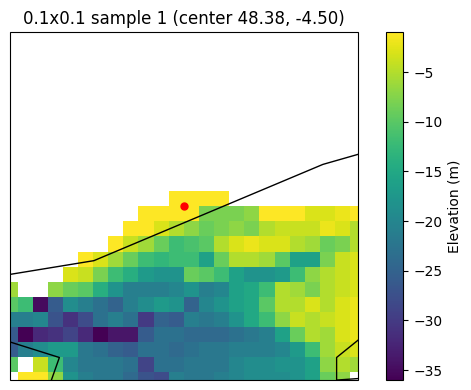

Skipping 0.1x0.1 tile 2: lat=0, lon=24


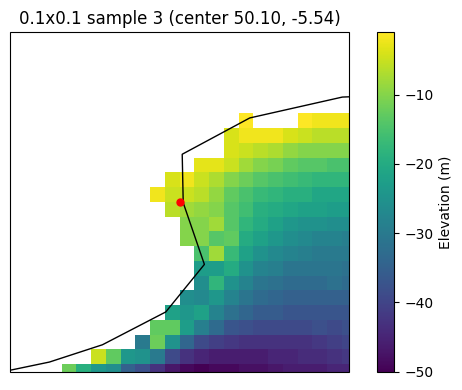

Plotting 3 tiles from 0.25x0.25


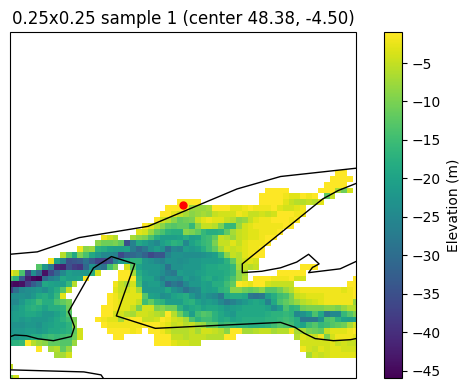

Skipping 0.25x0.25 tile 2: lat=0, lon=60


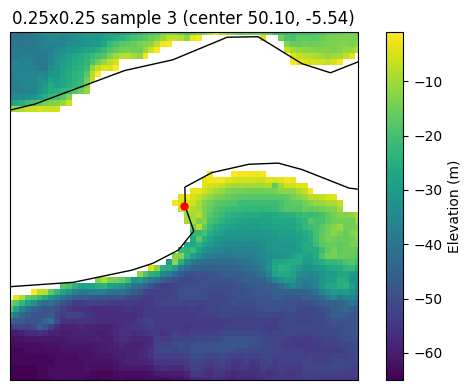

Plotting 3 tiles from 1x1


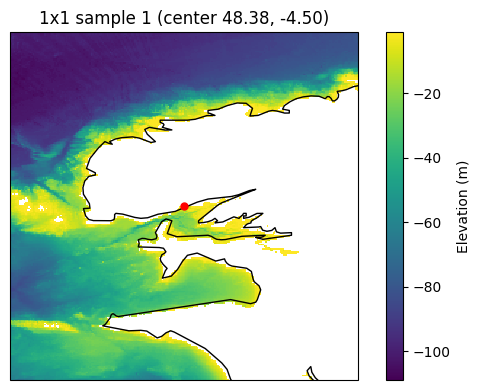

Skipping 1x1 tile 2: lat=0, lon=240


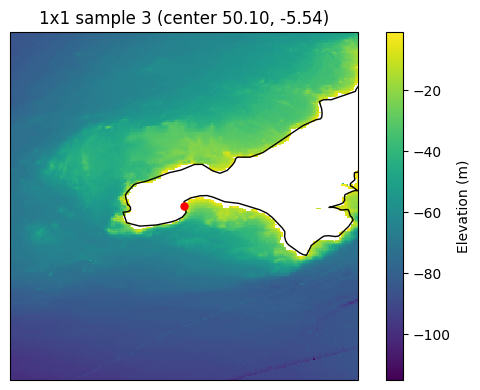

Plotting 3 tiles from 3x3


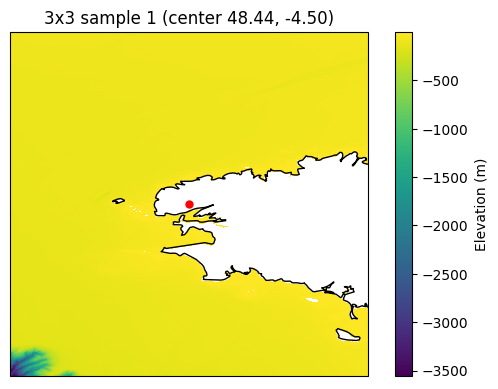

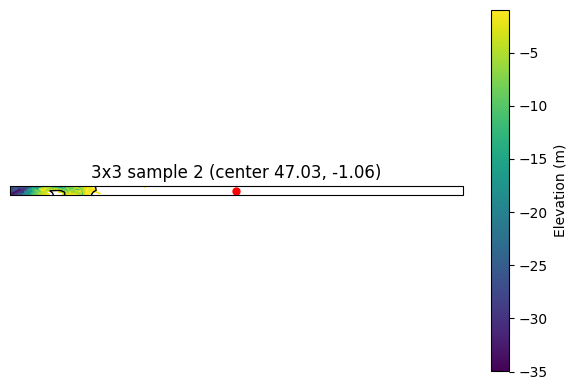

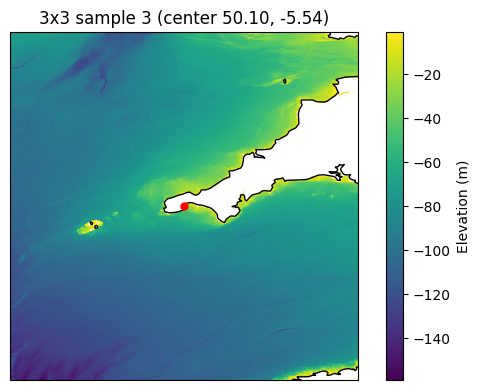

Plotting 3 tiles from 10x10


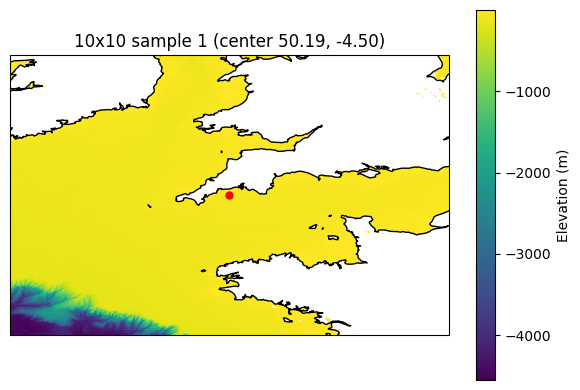

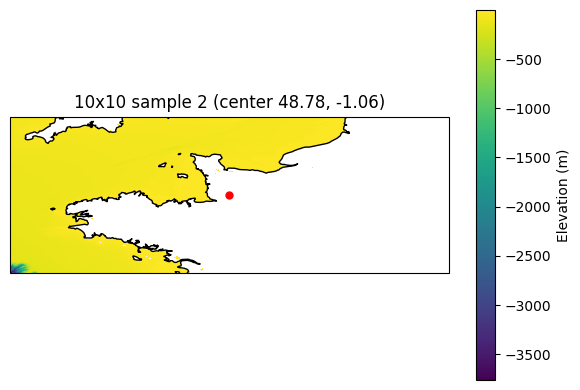

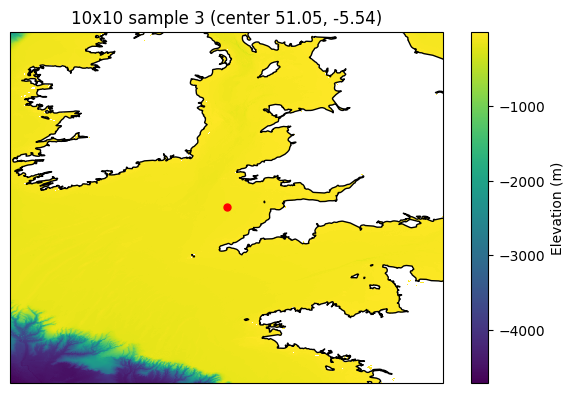

In [89]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

def plot_results_bathymetry(results, max_per_size=3):
    for key, tiles in results.items():
        if not tiles:
            print(f"No tiles in {key}")
            continue

        print(f"Plotting {min(len(tiles), max_per_size)} tiles from {key}")
        for i, ds_tile in enumerate(tiles[:max_per_size]):

            # mask shallow elevations
            ds_masked = ds_tile.copy()
            ds_masked["elevation"] = ds_tile["elevation"].where(ds_tile["elevation"] <= -0.5)

            # guard against empty/degenerate tiles
            lat_n = ds_masked.dims.get("lat", 0)
            lon_n = ds_masked.dims.get("lon", 0)
            if lat_n < 2 or lon_n < 2:
                print(f"Skipping {key} tile {i+1}: lat={lat_n}, lon={lon_n}")
                continue

            # tile center (coordinate midpoint, not necessarily station)
            center_lat = float(ds_masked["lat"].values.mean())
            center_lon = float(ds_masked["lon"].values.mean())

            fig = plt.figure(figsize=(6, 4))
            ax = plt.axes(projection=ccrs.PlateCarree())

            LON, LAT = np.meshgrid(ds_masked["lon"].values, ds_masked["lat"].values)
            Z = ds_masked["elevation"].values

            pcm = ax.pcolormesh(
                LON, LAT, Z,
                transform=ccrs.PlateCarree(),
                shading="auto"
            )

            ax.coastlines(resolution="10m")
            ax.set_extent(
                [float(ds_masked.lon.min()), float(ds_masked.lon.max()),
                 float(ds_masked.lat.min()), float(ds_masked.lat.max())],
                crs=ccrs.PlateCarree()
            )

            ax.set_title(f"{key} sample {i+1} (center {center_lat:.2f}, {center_lon:.2f})")
            ax.plot(center_lon, center_lat, "ro", markersize=5, transform=ccrs.PlateCarree())

            plt.colorbar(pcm, ax=ax, label="Elevation (m)")
            plt.tight_layout()
            plt.show()

# Example usage
plot_results_bathymetry(results, max_per_size=3)

In [61]:
stats_df.lon.head()

0   -4.495
1   -4.495
2   -4.495
3   -4.495
4   -4.495
Name: lon, dtype: float64

near 0 wind is close to cross-shore/onshore

In [ ]:
stats_df.to_csv("DIff_GEV_station_variable_statistics.csv", index=False)

In [ ]:
import pandas as pd

def column_catalog(stats_df: pd.DataFrame) -> pd.DataFrame:
    cols = list(stats_df.columns)
    labels = pd.Series(index=cols, dtype="object")

    # ---- rules (in precedence order) ----

    # LOCATION
    for c in ("station", "lon", "lat"):
        if c in labels.index:
            labels.loc[c] = "LOCATION"

    # SEALEVEL_TARGET: anything containing "residual"
    residual_cols = [c for c in cols if "residual" in c.lower()]
    labels.loc[residual_cols] = "SEALEVEL_TARGET"

    # RELATIVE_BAY: anything with degrees
    deg_cols = [c for c in cols if c.endswith("_deg")]
    labels.loc[deg_cols] = "RELATIVE_BAY"

    # WEATHER: ERA5 vars + derivatives of those vars (e.g., u10_abs, tau_u_abs, etc.)
    era5_bases = ["u10", "v10", "d2m", "t2m", "msl", "sst", "sp", "tp", "mwd", "mwp", "swh"]
    weather_cols = []
    for c in cols:
        c_low = c.lower()
        if c in era5_bases:
            weather_cols.append(c)
            continue
        # derivatives like u10_abs, v10_abs, tp_something, etc.
        if any(c.startswith(base + "_") for base in era5_bases):
            weather_cols.append(c)
            continue
        # common derived-from-wind/wave diagnostics present in your df
        if c_low.startswith(("tau_", "wind_")) or c_low in ("wind_dir",):
            weather_cols.append(c)
            continue

    # Only set WEATHER where not already set by higher-precedence rules
    for c in weather_cols:
        if pd.isna(labels.loc[c]):
            labels.loc[c] = "WEATHER"

    # everything else
    labels = labels.fillna("OTHER")

    # return a tidy table "next to" the column names
    return pd.DataFrame({"column": labels.index, "label": labels.values})


# usage
catalog_df = column_catalog(stats_df)